# Langkah 1: Audit Data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

cab_rides_path = project_root / "data" / "raw" / "cab_rides.csv"
weather_path = project_root / "data" / "raw" / "weather.csv"

print("Cab rides path:", cab_rides_path)
print("Weather path:", weather_path)





Cab rides path: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\data\raw\cab_rides.csv
Weather path: D:\SEMESTER 6\DATA MINING\MLOps-Tarif-Transportasi-Online\data\raw\weather.csv


In [2]:
cab_rides = pd.read_csv(cab_rides_path)
weather = pd.read_csv(weather_path)

print("5 baris pertama dari cab_rides.csv")
display(cab_rides.head())

print("5 baris pertama dari weather.csv")
display(weather.head())





5 baris pertama dari cab_rides.csv


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


5 baris pertama dari weather.csv


,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


In [3]:
dataset_shapes = pd.DataFrame({
    "Dataset": ["cab_rides", "weather"],
    "Rows": [cab_rides.shape[0], weather.shape[0]],
    "Columns": [cab_rides.shape[1], weather.shape[1]],
})

display(dataset_shapes)





,Dataset,Rows,Columns
0,cab_rides,693071,10
1,weather,5,8


# Langkah 2: Inspeksi Kolom


In [4]:
print("Cab rides columns:")
display(pd.DataFrame({"column_name": cab_rides.columns}))

print("Weather columns:")
display(pd.DataFrame({"column_name": weather.columns}))





Cab rides columns:


,column_name
0,distance
1,cab_type
2,time_stamp
3,destination
4,source
5,price
6,surge_multiplier
7,id
8,product_id
9,name


Weather columns:


,column_name
0,temp
1,location
2,clouds
3,pressure
4,rain
5,time_stamp
6,humidity
7,wind


In [5]:
print("Cab rides data types:")
display(cab_rides.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"}))

print("Weather data types:")
display(weather.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"}))





Cab rides data types:


,column_name,data_type
0,distance,float64
1,cab_type,object
2,time_stamp,int64
3,destination,object
4,source,object
5,price,float64
6,surge_multiplier,float64
7,id,object
8,product_id,object
9,name,object


Weather data types:


,column_name,data_type
0,temp,float64
1,location,object
2,clouds,float64
3,pressure,float64
4,rain,float64
5,time_stamp,int64
6,humidity,float64
7,wind,float64


# Langkah 3: Target Prediksi


In [6]:
print("Cab rides basic statistics:")
display(cab_rides.describe(include="all").T)

print("Weather basic statistics:")
display(weather.describe(include="all").T)





Cab rides basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distance,693071.0,NaN,NaN,NaN,2.18943,1.138937,0.02,1.28,2.16,2.92,7.86
cab_type,693071,2,Uber,385663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_stamp,693071.0,NaN,NaN,NaN,1544045709764.357178,689192492.400411,1543203646318.0,1543443968356.5,1543737477529.0,1544827508976.5,1545160510943.0
destination,693071,12,Financial District,58851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,693071,12,Financial District,58857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,637976.0,NaN,NaN,NaN,16.545125,9.324359,2.5,9.0,13.5,22.5,97.5
surge_multiplier,693071.0,NaN,NaN,NaN,1.01387,0.091641,1.0,1.0,1.0,1.0,3.0
id,693071,693071,e7fdc087-fe86-40a5-a3c3-3b2a8badcbda,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,693071,13,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,693071,13,UberXL,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Weather basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temp,5.0,NaN,NaN,NaN,42.518,0.373724,42.11,42.42,42.43,42.5,43.13
location,5,5,Back Bay,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clouds,5.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
pressure,5.0,NaN,NaN,NaN,1012.142,0.008367,1012.13,1012.14,1012.14,1012.15,1012.15
rain,5.0,NaN,NaN,NaN,0.13836,0.040578,0.0969,0.1089,0.1228,0.1786,0.1846
time_stamp,5.0,NaN,NaN,NaN,1545003901.0,0.0,1545003901.0,1545003901.0,1545003901.0,1545003901.0,1545003901.0
humidity,5.0,NaN,NaN,NaN,0.762,0.008367,0.75,0.76,0.76,0.77,0.77
wind,5.0,NaN,NaN,NaN,11.244,0.173436,11.07,11.09,11.25,11.32,11.49


In [7]:
cab_numeric_columns = cab_rides.select_dtypes(include=np.number).columns.tolist()
cab_categorical_columns = cab_rides.select_dtypes(exclude=np.number).columns.tolist()

weather_numeric_columns = weather.select_dtypes(include=np.number).columns.tolist()
weather_categorical_columns = weather.select_dtypes(exclude=np.number).columns.tolist()

print("Cab rides numerical columns:", cab_numeric_columns)
print("Cab rides categorical columns:", cab_categorical_columns)
print("Weather numerical columns:", weather_numeric_columns)
print("Weather categorical columns:", weather_categorical_columns)





Cab rides numerical columns: ['distance', 'time_stamp', 'price', 'surge_multiplier']
Cab rides categorical columns: ['cab_type', 'destination', 'source', 'id', 'product_id', 'name']
Weather numerical columns: ['temp', 'clouds', 'pressure', 'rain', 'time_stamp', 'humidity', 'wind']
Weather categorical columns: ['location']


# Langkah 4: Cek Missing Values


# Langkah 3b: Analisis Target dan Fitur

Target prediksi utama adalah `price`. Karena `price` berupa angka, ini termasuk masalah regresi.


In [8]:
target_column = "price"

if target_column in cab_rides.columns:
    print("Target column 'price' exists in cab_rides.csv.")
else:
    print("Target column 'price' is missing. This must be fixed before modeling.")





Target column 'price' exists in cab_rides.csv.


# Langkah 5: Cek Data Negatif


Price distribution using basic statistics:


,price
count,637976.000000
mean,16.545125
std,9.324359
min,2.500000
25%,9.000000
50%,13.500000
75%,22.500000
max,97.500000


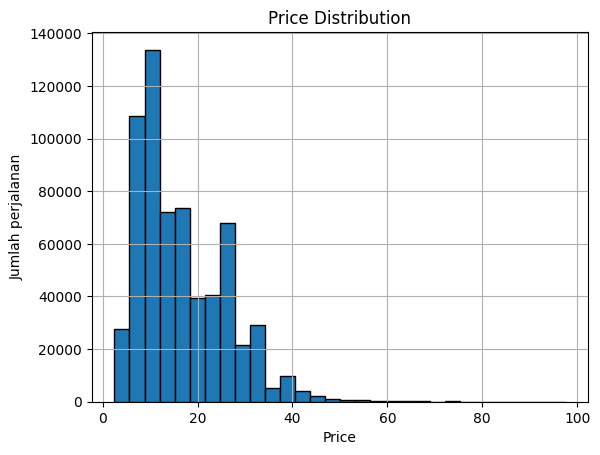

In [9]:
print("Price distribution using basic statistics:")
display(cab_rides["price"].describe().to_frame("price"))

cab_rides["price"].dropna().hist(bins=30, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Jumlah perjalanan")
plt.show()





Distribusi jarak dengan statistik dasar:


,distance
count,693071.000000
mean,2.189430
std,1.138937
min,0.020000
25%,1.280000
50%,2.160000
75%,2.920000
max,7.860000


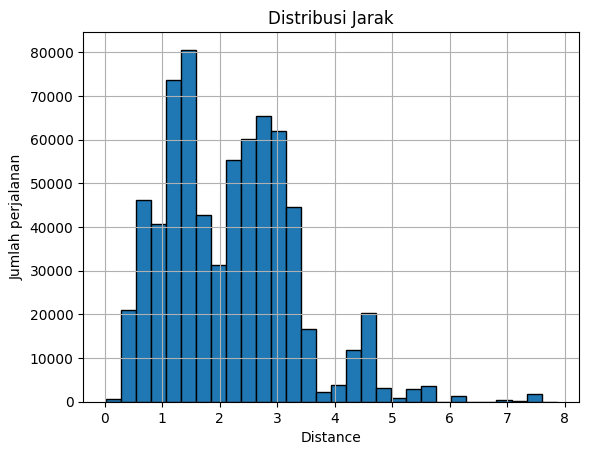

In [10]:
print("Distribusi jarak dengan statistik dasar:")
display(cab_rides["distance"].describe().to_frame("distance"))

cab_rides["distance"].dropna().hist(bins=30, edgecolor="black")
plt.title("Distribusi Jarak")
plt.xlabel("Distance")
plt.ylabel("Jumlah perjalanan")
plt.show()





In [11]:
for column in ["cab_type", "source", "destination", "name"]:
    print(f"Value counts for {column}:")
    display(cab_rides[column].value_counts(dropna=False).rename_axis(column).reset_index(name="count"))





Value counts for cab_type:


,cab_type,count
0,Uber,385663
1,Lyft,307408


Value counts for source:


,source,count
0,Financial District,58857
1,Theatre District,57813
2,Back Bay,57792
3,Boston University,57764
4,North End,57763
5,Fenway,57757
6,Northeastern University,57756
7,South Station,57750
8,Haymarket Square,57736
9,West End,57562


Value counts for destination:


,destination,count
0,Financial District,58851
1,Theatre District,57798
2,Back Bay,57780
3,Haymarket Square,57764
4,Boston University,57764
5,Fenway,57757
6,North End,57756
7,Northeastern University,57755
8,South Station,57749
9,West End,57575


Value counts for name:


,name,count
0,UberXL,55096
1,WAV,55096
2,Black SUV,55096
3,Black,55095
4,Taxi,55095
5,UberX,55094
6,UberPool,55091
7,Lux,51235
8,Lux Black XL,51235
9,Lyft,51235


# Langkah 6: Cek Duplikat


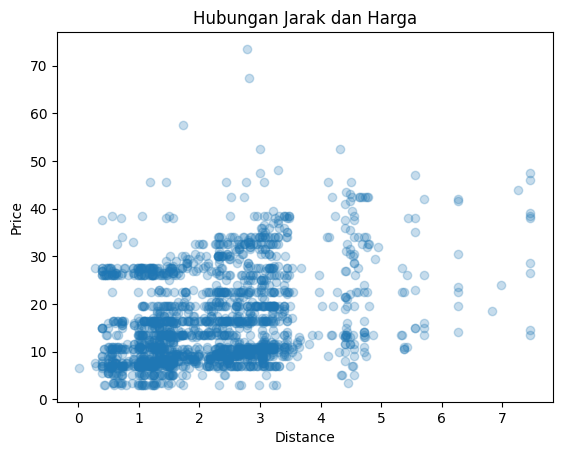

In [12]:
valid_price_distance = cab_rides[(cab_rides["price"].notna()) & (cab_rides["distance"] > 0)]
plot_sample = valid_price_distance.sample(n=min(2000, len(valid_price_distance)), random_state=42)

plt.scatter(plot_sample["distance"], plot_sample["price"], alpha=0.25)
plt.title("Hubungan Jarak dan Harga")
plt.xlabel("Distance")
plt.ylabel("Price")
plt.show()





# Langkah 4b: Validasi Kualitas Data

Validasi data merupakan bagian CI (Continuous Integration) di pipeline MLOps. Validasi memastikan data aman sebelum masuk proses training.


In [13]:
print("Total missing values per column in cab_rides:")
display(cab_rides.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index().rename(columns={"index": "column_name"}))

print("Total missing values per column in weather:")
display(weather.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index().rename(columns={"index": "column_name"}))





Total missing values per column in cab_rides:


,column_name,missing_values
0,price,55095
1,distance,0
2,cab_type,0
3,time_stamp,0
4,destination,0
5,source,0
6,surge_multiplier,0
7,id,0
8,product_id,0
9,name,0


Total missing values per column in weather:


,column_name,missing_values
0,temp,0
1,location,0
2,clouds,0
3,pressure,0
4,rain,0
5,time_stamp,0
6,humidity,0
7,wind,0


# Langkah 7: Kesimpulan Audit


In [14]:
row_checks = {
    "Harga kosong": cab_rides["price"].isna(),
    "Distance <= 0": cab_rides["distance"] <= 0,
    "Price <= 0": cab_rides["price"] <= 0,
    "Asal kosong": cab_rides["source"].isna(),
    "Tujuan kosong": cab_rides["destination"].isna(),
    "Tipe layanan kosong": cab_rides["cab_type"].isna(),
    "Nama layanan kosong": cab_rides["name"].isna(),
}

row_check_summary = pd.DataFrame({
    "Check Name": list(row_checks.keys()),
    "Failed Rows": [int(mask.sum()) for mask in row_checks.values()],
})

display(row_check_summary)





,Check Name,Failed Rows
0,Harga kosong,55095
1,Distance <= 0,0
2,Price <= 0,0
3,Asal kosong,0
4,Tujuan kosong,0
5,Tipe layanan kosong,0
6,Nama layanan kosong,0


In [15]:
def missing_percentage_table(df, dataset_name):
    missing_count = df.isna().sum()
    missing_percentage = missing_count / len(df) * 100
    return pd.DataFrame({
        "dataset": dataset_name,
        "column_name": df.columns,
        "missing_values": missing_count.values,
        "missing_percentage": missing_percentage.round(2).values,
    })

missing_percentage_summary = pd.concat([
    missing_percentage_table(cab_rides, "cab_rides"),
    missing_percentage_table(weather, "weather"),
], ignore_index=True)

display(missing_percentage_summary)





,dataset,column_name,missing_values,missing_percentage
0,cab_rides,distance,0,0.00
1,cab_rides,cab_type,0,0.00
2,cab_rides,time_stamp,0,0.00
3,cab_rides,destination,0,0.00
4,cab_rides,source,0,0.00
5,cab_rides,price,55095,7.95
6,cab_rides,surge_multiplier,0,0.00
7,cab_rides,id,0,0.00
8,cab_rides,product_id,0,0.00
9,cab_rides,name,0,0.00


In [16]:
def status_from_count(failed_rows, issue_status):
    if failed_rows == 0:
        return "PASS"
    return issue_status

price_column_failed = 0 if "price" in cab_rides.columns else len(cab_rides)
missing_price_failed = int(cab_rides["price"].isna().sum()) if "price" in cab_rides.columns else len(cab_rides)
price_le_zero_failed = int((cab_rides["price"] <= 0).sum()) if "price" in cab_rides.columns else len(cab_rides)
weather_rain_missing = int(weather["rain"].isna().sum()) if "rain" in weather.columns else 0

validation_summary = pd.DataFrame([
    {
        "Check Name": "Kolom target ada",
        "Rule": "Kolom price harus ada",
        "Failed Rows": price_column_failed,
        "Status": status_from_count(price_column_failed, "FAIL"),
        "Recommendation": "Gunakan price sebagai target.",
    },
    {
        "Check Name": "Harga kosong",
        "Rule": "Harga harus tersedia untuk training",
        "Failed Rows": missing_price_failed,
        "Status": status_from_count(missing_price_failed, "WARNING"),
        "Recommendation": "Hapus baris target kosong.",
    },
    {
        "Check Name": "Validitas jarak",
        "Rule": "Jarak harus > 0",
        "Failed Rows": int((cab_rides["distance"] <= 0).sum()),
        "Status": status_from_count(int((cab_rides["distance"] <= 0).sum()), "FAIL"),
        "Recommendation": "Hapus jarak tidak valid.",
    },
    {
        "Check Name": "Validitas harga",
        "Rule": "Harga harus > 0",
        "Failed Rows": price_le_zero_failed,
        "Status": status_from_count(price_le_zero_failed, "FAIL"),
        "Recommendation": "Hapus tarif tidak mungkin.",
    },
    {
        "Check Name": "Asal kosong",
        "Rule": "Asal tidak boleh kosong",
        "Failed Rows": int(cab_rides["source"].isna().sum()),
        "Status": status_from_count(int(cab_rides["source"].isna().sum()), "FAIL"),
        "Recommendation": "Hapus baris terdampak.",
    },
    {
        "Check Name": "Tujuan kosong",
        "Rule": "Tujuan tidak boleh kosong",
        "Failed Rows": int(cab_rides["destination"].isna().sum()),
        "Status": status_from_count(int(cab_rides["destination"].isna().sum()), "FAIL"),
        "Recommendation": "Hapus baris terdampak.",
    },
    {
        "Check Name": "Tipe layanan kosong",
        "Rule": "Tipe tidak boleh kosong",
        "Failed Rows": int(cab_rides["cab_type"].isna().sum()),
        "Status": status_from_count(int(cab_rides["cab_type"].isna().sum()), "FAIL"),
        "Recommendation": "Cek nilai platform yang hilang.",
    },
    {
        "Check Name": "Nama layanan kosong",
        "Rule": "Nama produk tidak boleh kosong",
        "Failed Rows": int(cab_rides["name"].isna().sum()),
        "Status": status_from_count(int(cab_rides["name"].isna().sum()), "WARNING"),
        "Recommendation": "Tangani nama kosong sebelum encoding.",
    },
    {
        "Check Name": "Baris duplikat",
        "Rule": "Baris duplikat harus direview",
        "Failed Rows": int(cab_rides.duplicated().sum()),
        "Status": status_from_count(int(cab_rides.duplicated().sum()), "WARNING"),
        "Recommendation": "Hapus duplikat.",
    },
    {
        "Check Name": "Hujan kosong",
        "Rule": "Data hujan harus dicek",
        "Failed Rows": weather_rain_missing,
        "Status": status_from_count(weather_rain_missing, "WARNING"),
        "Recommendation": "Isi hujan kosong dengan 0.",
    },
])

display(validation_summary)





,Check Name,Rule,Failed Rows,Status,Recommendation
0,Kolom target ada,Kolom price harus ada,0,PASS,Gunakan price sebagai target.
1,Harga kosong,Harga harus tersedia untuk training,55095,WARNING,Hapus baris target kosong.
2,Validitas jarak,Jarak harus > 0,0,PASS,Hapus jarak tidak valid.
3,Validitas harga,Harga harus > 0,0,PASS,Hapus tarif tidak mungkin.
4,Asal kosong,Asal tidak boleh kosong,0,PASS,Hapus baris terdampak.
5,Tujuan kosong,Tujuan tidak boleh kosong,0,PASS,Hapus baris terdampak.
6,Tipe layanan kosong,Tipe tidak boleh kosong,0,PASS,Cek nilai platform yang hilang.
7,Nama layanan kosong,Nama produk tidak boleh kosong,0,PASS,Tangani nama kosong sebelum encoding.
8,Baris duplikat,Baris duplikat harus direview,0,PASS,Hapus duplikat.
9,Hujan kosong,Data hujan harus dicek,0,PASS,Isi hujan kosong dengan 0.


# Langkah 8: Catatan Temuan Awal

Temuan utama dari audit ini:
- Dataset perjalanan memiliki kolom target `price` yang bisa dipakai.
- Ada 55.095 baris tanpa harga yang harus dibuang.
- Data cuaca belum digabung.
- Semua pengecekan ini jadi dasar checklist CI.


In [17]:
valid_price_rows = int(cab_rides["price"].notna().sum())
missing_price_rows = int(cab_rides["price"].isna().sum())
invalid_distance_rows = int((cab_rides["distance"] <= 0).sum())

final_summary = pd.DataFrame({
    "Metric": [
        "Jumlah baris cab_rides",
        "Jumlah baris weather",
        "Jumlah kolom cab_rides",
        "Jumlah kolom weather",
        "Jumlah baris harga valid",
        "Jumlah baris harga kosong",
        "Jumlah baris jarak invalid",
        "Kolom target yang disarankan",
        "Tipe masalah machine learning",
    ],
    "Value": [
        f"{len(cab_rides):,}",
        f"{len(weather):,}",
        cab_rides.shape[1],
        weather.shape[1],
        f"{valid_price_rows:,}",
        f"{missing_price_rows:,}",
        f"{invalid_distance_rows:,}",
        "price",
        "Regression",
    ],
})

display(final_summary)

print("Ringkasan singkat akhir")
for _, row in final_summary.iterrows():
    print(f"{row['Metric']}: {row['Value']}")





,Metric,Value
0,Jumlah baris cab_rides,"693,071"
1,Jumlah baris weather,5
2,Jumlah kolom cab_rides,10
3,Jumlah kolom weather,8
4,Jumlah baris harga valid,"637,976"
5,Jumlah baris harga kosong,"55,095"
6,Jumlah baris jarak invalid,0
7,Kolom target yang disarankan,price
8,Tipe masalah machine learning,Regression


Ringkasan singkat akhir
Jumlah baris cab_rides: 693,071
Jumlah baris weather: 5
Jumlah kolom cab_rides: 10
Jumlah kolom weather: 8
Jumlah baris harga valid: 637,976
Jumlah baris harga kosong: 55,095
Jumlah baris jarak invalid: 0
Kolom target yang disarankan: price
Tipe masalah machine learning: Regression
